# EN3160 Assignment 1,

Shakthi Gamage.

Index number: 230195F

GitHub repo: https://github.com/GamageShakthi/Image-Processing-Assignment

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

base_path = r"C:\Users\SHAKTHI\Desktop\Image processing\Assignment_1"
img_path = os.path.join(base_path, "images")

plt.rcParams['figure.figsize'] = (9, 5)
np.random.seed(0)

## Q1, 

In [2]:
def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints)
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]
    lut = np.zeros(256, dtype=np.float32)
    for i in range(len(x) - 1):
        x1, x2 = x[i], x[i + 1]
        y1, y2 = y[i], y[i + 1]
        if x2 == x1:
            continue
        xs = np.arange(x1, x2 + 1)
        lut[xs] = y1 + (y2 - y1) * (xs - x1) / (x2 - x1)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[im]

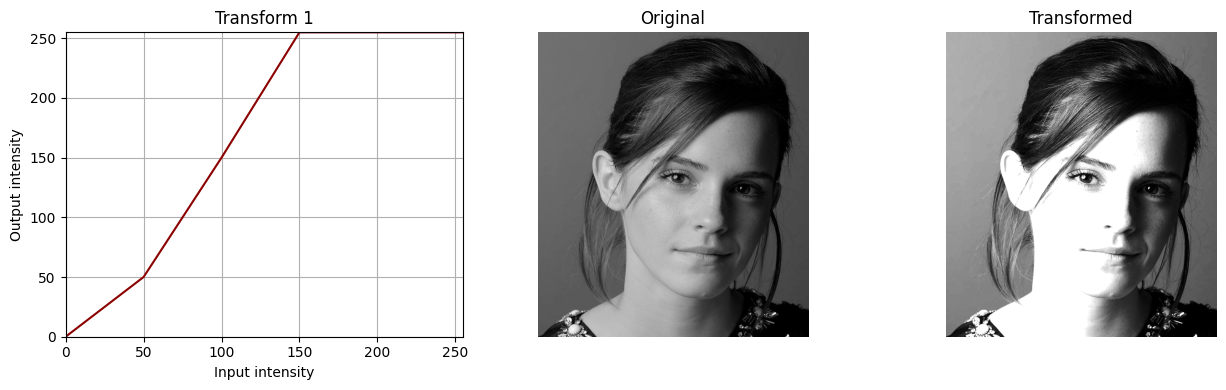

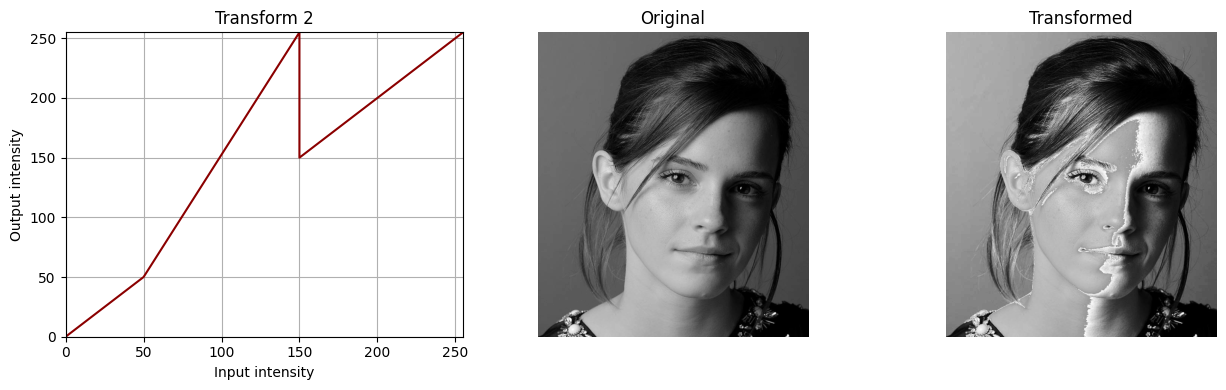

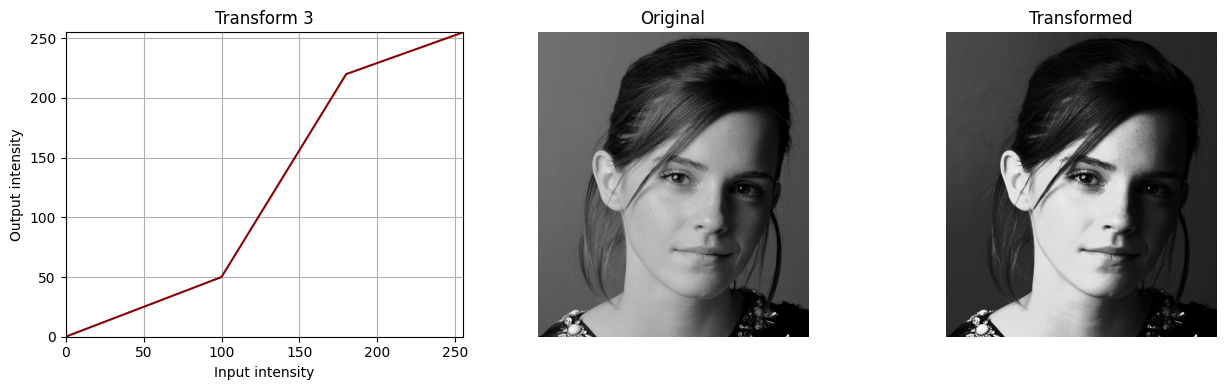

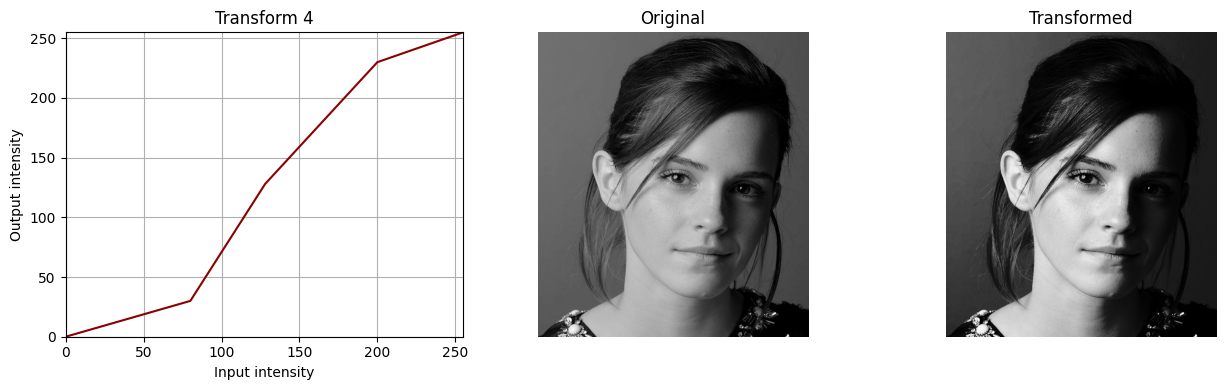

In [3]:
img1 = cv2.imread(os.path.join(img_path, "q1.jpeg"), cv2.IMREAD_GRAYSCALE)

breakpoint_sets = [
    [[0, 0], [50, 50], [100, 150], [150, 255], [255, 255]],
    [[0, 0], [50, 50], [150, 255], [150, 150], [255, 255]],
    [[0, 0], [100, 50], [180, 220], [255, 255]],
    [[0, 0], [80, 30], [128, 128], [200, 230], [255, 255]],
]

for idx, breakpoints_q1 in enumerate(breakpoint_sets):
    img1_transformed = intensity_transform(img1, breakpoints_q1)

    bp = np.array(breakpoints_q1)

    fig, axs = plt.subplots(1, 3, figsize=(13, 4))

    axs[0].plot(bp[:, 0], bp[:, 1], color='darkred')
    axs[0].set_xlim(0, 255)
    axs[0].set_ylim(0, 255)
    axs[0].set_xlabel("Input intensity")
    axs[0].set_ylabel("Output intensity")
    axs[0].set_title(f"Transform {idx + 1}")
    axs[0].grid(True)

    axs[1].imshow(img1, cmap='gray')
    axs[1].set_title("Original")
    axs[1].axis('off')

    axs[2].imshow(img1_transformed, cmap='gray')
    axs[2].set_title("Transformed")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

I tried four different breakpoint sets. The first one just brightens the midtones a bit. The second one has a sharp drop at 150 which creates a weird jump in brightness, not very useful visually. The third one is a simple S curve that increases contrast. The fourth one has more control points and gives a smoother contrast boost. Out of these, the third one gave the most visually pleasing result since it increases contrast without introducing any sudden jumps, so I picked that as the final transformation for this image.

## Q2, 
Same idea as question 1 but applied on the brain scan. White matter pixels are the brightest regions in the image and gray matter pixels sit in the middle range. breakpoints that push one of these ranges toward white and squash everything else toward black.

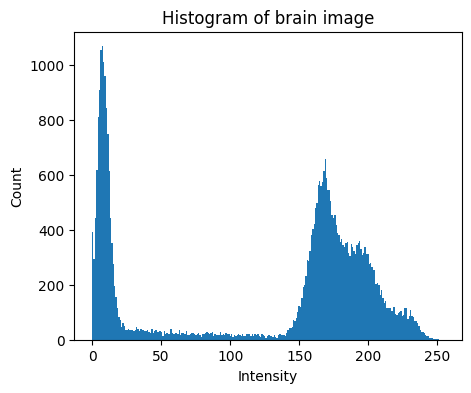

In [4]:
img2 = cv2.imread(os.path.join(img_path, "q2.jpeg"), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5, 4))
plt.hist(img2.ravel(), bins=256, range=(0, 255))
plt.title("Histogram of brain image")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.show()

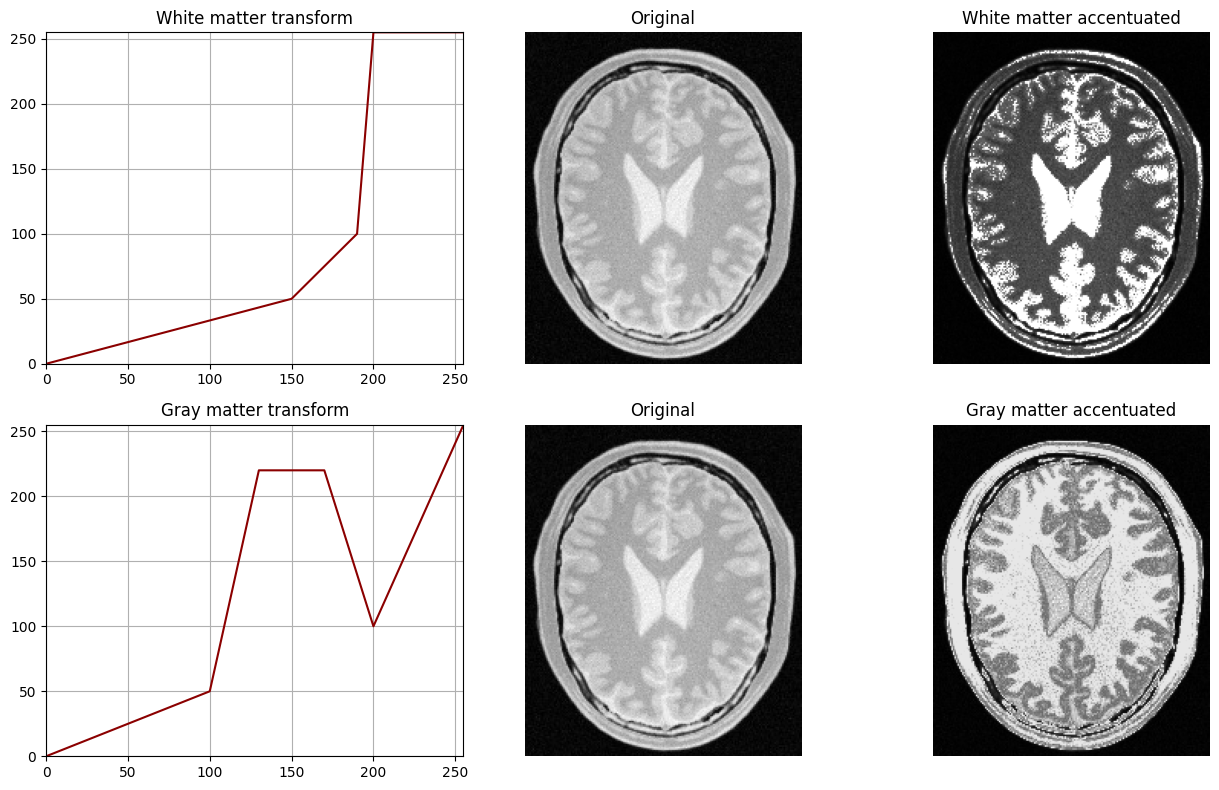

In [5]:
breakpoints_white = [[0, 0], [150, 50], [190, 100], [200, 255], [230, 255], [255, 255]]

breakpoints_gray = [[0, 0], [100, 50], [130, 220], [170, 220], [200, 100], [255, 255]]

img2_white = intensity_transform(img2, breakpoints_white)
img2_gray = intensity_transform(img2, breakpoints_gray)

fig, axs = plt.subplots(2, 3, figsize=(13, 8))

bp_w = np.array(breakpoints_white)
axs[0, 0].plot(bp_w[:, 0], bp_w[:, 1], color='darkred')
axs[0, 0].set_xlim(0, 255)
axs[0, 0].set_ylim(0, 255)
axs[0, 0].set_title("White matter transform")
axs[0, 0].grid(True)

axs[0, 1].imshow(img2, cmap='gray')
axs[0, 1].set_title("Original")
axs[0, 1].axis('off')

axs[0, 2].imshow(img2_white, cmap='gray')
axs[0, 2].set_title("White matter accentuated")
axs[0, 2].axis('off')

bp_g = np.array(breakpoints_gray)
axs[1, 0].plot(bp_g[:, 0], bp_g[:, 1], color='darkred')
axs[1, 0].set_xlim(0, 255)
axs[1, 0].set_ylim(0, 255)
axs[1, 0].set_title("Gray matter transform")
axs[1, 0].grid(True)

axs[1, 1].imshow(img2, cmap='gray')
axs[1, 1].set_title("Original")
axs[1, 1].axis('off')

axs[1, 2].imshow(img2_gray, cmap='gray')
axs[1, 2].set_title("Gray matter accentuated")
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()

For white matter, I stretched the intensity range around 190 to 230 since that is where white matter sits, and compressed everything else so those areas stand out brighter against the rest of the brain.

For gray matter, I boosted the mid range around 100 to 200 while compressing the higher intensities, this brings out the gray matter regions more clearly without letting white matter dominate the image.

I got these ranges by looking at the histogram of the image and roughly matching them to where white matter and gray matter pixels cluster.

## Q3, 
I convert the image to the Lab color space, apply gamma correction only on the L channel and convert back. Applying gamma only on L keeps the colors (a,b) untouched so we only change brightness and contrast, not the actual hue.

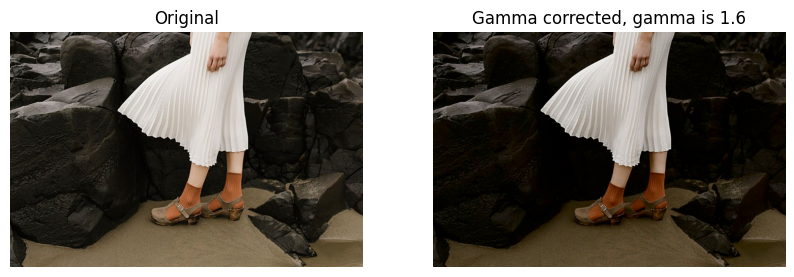

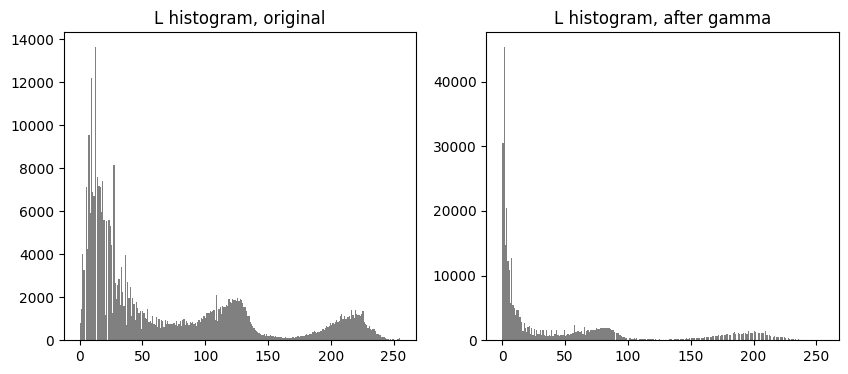

In [9]:
img3 = cv2.imread(os.path.join(img_path, "q3.jpeg"))
lab3 = cv2.cvtColor(img3, cv2.COLOR_BGR2LAB)
L3, A3, B3 = cv2.split(lab3)

gamma = 1.6

L3_norm = L3.astype(np.float32) / 255.0
L3_gamma = np.power(L3_norm, gamma) * 255.0
L3_gamma = np.clip(L3_gamma, 0, 255).astype(np.uint8)

lab3_gamma = cv2.merge([L3_gamma, A3, B3])
img3_gamma = cv2.cvtColor(lab3_gamma, cv2.COLOR_LAB2BGR)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(img3_gamma, cv2.COLOR_BGR2RGB)); ax[1].set_title(f"Gamma corrected, gamma is {gamma}"); ax[1].axis('off')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(L3.ravel(), bins=256, range=(0, 255), color='gray')
ax[0].set_title("L histogram, original")
ax[1].hist(L3_gamma.ravel(), bins=256, range=(0, 255), color='gray')
ax[1].set_title("L histogram, after gamma")
plt.show()

USED GAMMA VALUE = 1.6


There is a folded skirt and darker rocks in the shadow, so I used a gamma value greater than 1. Since gamma is applied as L raised to the power gamma on the normalized 0 to 1 scale, a gamma above 1 pushes midtones down and pulls some of the blown out highlights, so the rocks keep its texture while the white skirt does not look too flat. The histogram after correction is shifted toward the darker side and looks a bit more spread out compared to the original which was bunched up near the bright end.

## Q4,

I split the image into hue, saturation and value planes, then boost the saturation plane with the bump function.

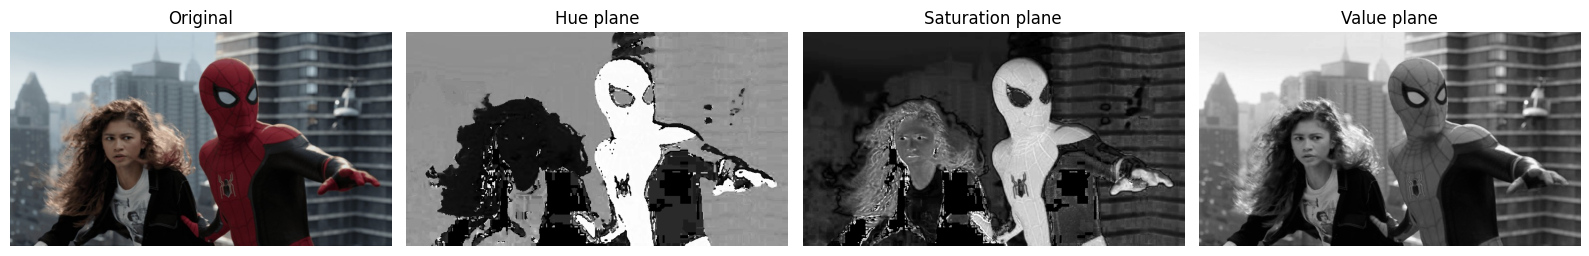

In [8]:
img4 = cv2.imread(os.path.join(img_path, "q4.jpeg"))
img4_rgb = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

hsv4 = cv2.cvtColor(img4, cv2.COLOR_BGR2HSV)
h_plane, s_plane, v_plane = cv2.split(hsv4)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

axs[0].imshow(img4_rgb)
axs[0].set_title("Original")
axs[0].axis('off')

axs[1].imshow(h_plane, cmap='gray')
axs[1].set_title("Hue plane")
axs[1].axis('off')

axs[2].imshow(s_plane, cmap='gray')
axs[2].set_title("Saturation plane")
axs[2].axis('off')

axs[3].imshow(v_plane, cmap='gray')
axs[3].set_title("Value plane")
axs[3].axis('off')

plt.tight_layout()
plt.show()

In [9]:
def vibrance_transform(x, a, sigma=70):
    x = x.astype(np.float64)
    boost = a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
    out = x + boost
    out = np.clip(out, 0, 255)
    return out.astype(np.uint8)

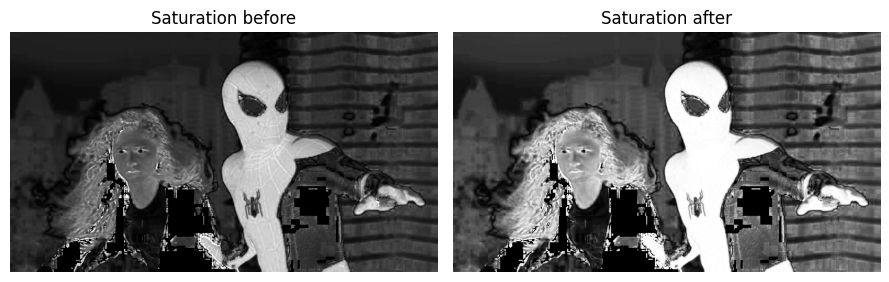

In [14]:
a = 0.7

s_plane_new = vibrance_transform(s_plane, a)

fig, axs = plt.subplots(1, 2, figsize=(9, 4))
axs[0].imshow(s_plane, cmap='gray')
axs[0].set_title("Saturation before")
axs[0].axis('off')

axs[1].imshow(s_plane_new, cmap='gray')
axs[1].set_title("Saturation after")
axs[1].axis('off')

plt.tight_layout()
plt.show()

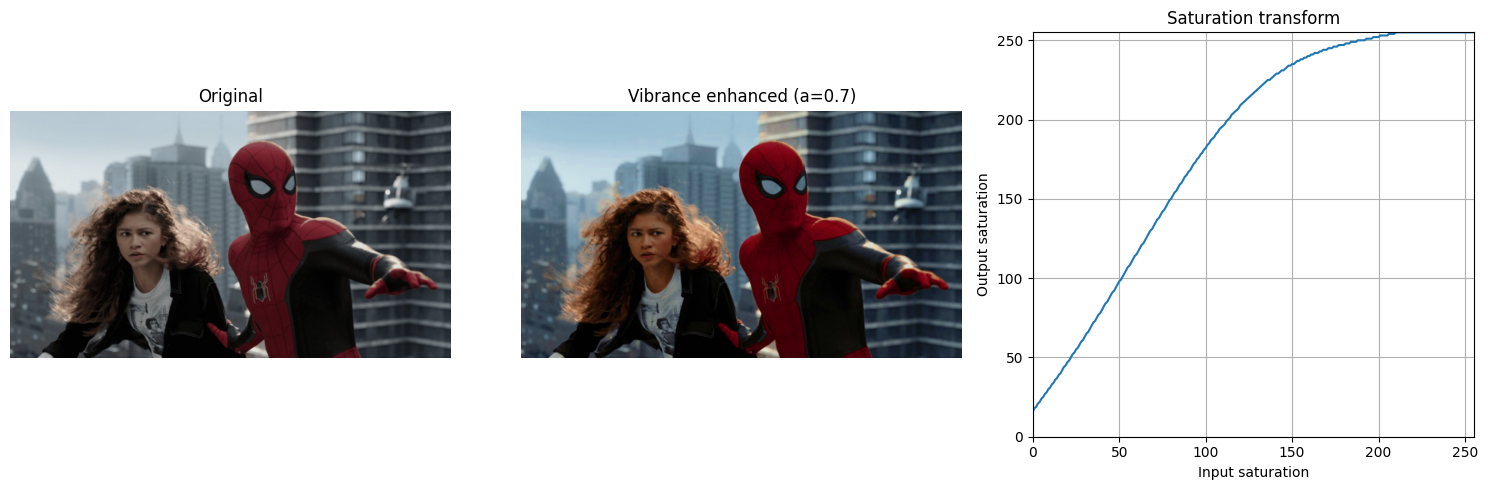

In [15]:
hsv4_new = cv2.merge([h_plane, s_plane_new, v_plane])
img4_result = cv2.cvtColor(hsv4_new, cv2.COLOR_HSV2BGR)
img4_result_rgb = cv2.cvtColor(img4_result, cv2.COLOR_BGR2RGB)

x_vals = np.arange(256)
y_vals = vibrance_transform(x_vals, a)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(img4_rgb)
axs[0].set_title("Original")
axs[0].axis('off')

axs[1].imshow(img4_result_rgb)
axs[1].set_title(f"Vibrance enhanced (a={a})")
axs[1].axis('off')

axs[2].plot(x_vals, y_vals)
axs[2].set_title("Saturation transform")
axs[2].set_xlabel("Input saturation")
axs[2].set_ylabel("Output saturation")
axs[2].set_xlim([0, 255])
axs[2].set_ylim([0, 255])
axs[2].grid(True)

plt.tight_layout()
plt.show()

The transform boosts mid range saturation values the most, since the bump function peaks around x=128, and leaves very low and very high saturation values mostly untouched. This means dull colors get more saturated but colors that are already vivid do not get pushed further, so nothing looks overblown.

I tried a values between 0 and 1. At a=0.7 the colors look noticeably more vibrant without looking fake, higher values like 0.9 started to look oversaturated in some areas, so I picked a=0.7 as the final value.

## Q5,

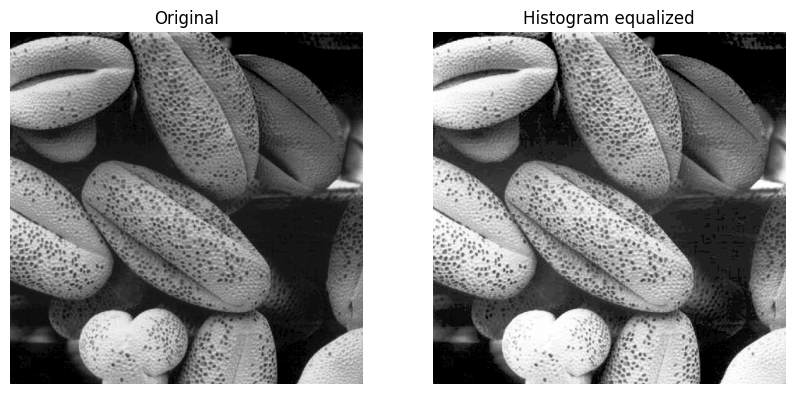

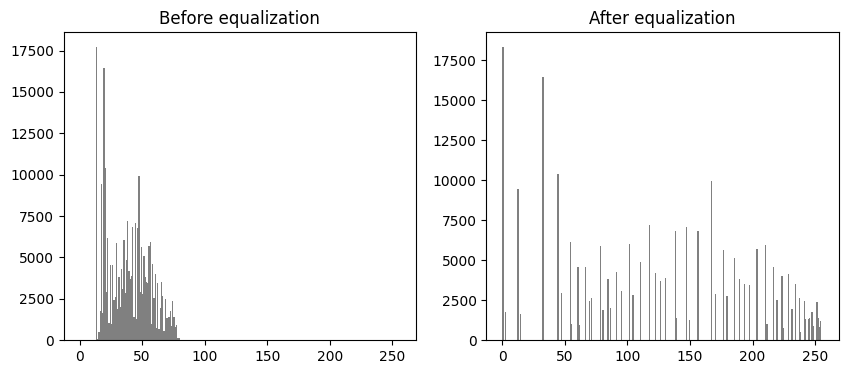

In [16]:
def my_hist_eq(im):
    hist, bins = np.histogram(im.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_masked = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
    lut = np.ma.filled(cdf_masked, 0).astype('uint8')
    return lut[im]

img5 = cv2.imread(os.path.join(img_path, "q5.tif"), cv2.IMREAD_GRAYSCALE)
img5_eq = my_hist_eq(img5)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(img5, cmap='gray'); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(img5_eq, cmap='gray'); ax[1].set_title("Histogram equalized"); ax[1].axis('off')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(img5.ravel(), 256, [0, 256], color='gray')
ax[0].set_title("Before equalization")
ax[1].hist(img5_eq.ravel(), 256, [0, 256], color='gray')
ax[1].set_title("After equalization")
plt.show()

The original leaf image has most of its pixel values crammed into a narrow dark range so the picture looks flat and low contrast. After equalization the histogram gets spread across almost the full 0 to 255 range and the picture shows more detail in the leaf texture and the small dark spots. I checked my output against cv2.equalizeHist and got the same result, so the implementation is correct.

## Q6,

Here the goal is to equalize only the foreground and leave the background alone. I split the image into HSV, use the saturation plane to build a mask that separates the person from the plain background, then equalize the value plane only inside mask.

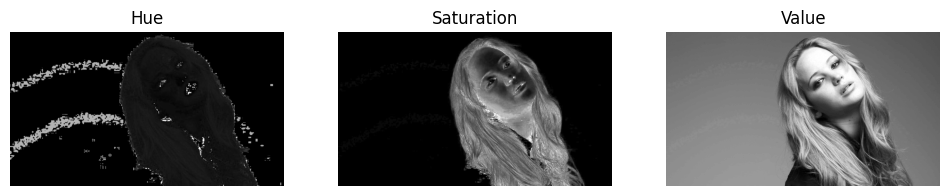

In [13]:
img6 = cv2.imread(os.path.join(img_path, "q6.jpeg"))
hsv6 = cv2.cvtColor(img6, cv2.COLOR_BGR2HSV)
H6, S6, V6 = cv2.split(hsv6)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(H6, cmap='gray'); ax[0].set_title("Hue"); ax[0].axis('off')
ax[1].imshow(S6, cmap='gray'); ax[1].set_title("Saturation"); ax[1].axis('off')
ax[2].imshow(V6, cmap='gray'); ax[2].set_title("Value"); ax[2].axis('off')
plt.show()

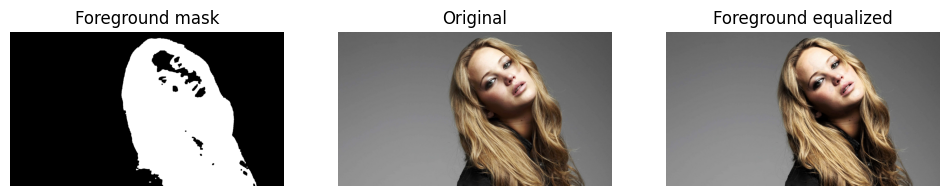

In [14]:
_, mask6 = cv2.threshold(S6, 45, 255, cv2.THRESH_BINARY)
mask6 = cv2.morphologyEx(mask6, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
mask6 = cv2.morphologyEx(mask6, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))

foreground6 = cv2.bitwise_and(V6, V6, mask=mask6)

hist_fg = cv2.calcHist([V6], [0], mask6, [256], [0, 256]).flatten()
cdf_fg = hist_fg.cumsum()
cdf_fg_norm = (cdf_fg - cdf_fg.min()) * 255 / (cdf_fg.max() - cdf_fg.min() + 1e-6)
lut_fg = cdf_fg_norm.astype('uint8')

fg_equalized = lut_fg[V6]
fg_equalized = cv2.bitwise_and(fg_equalized, fg_equalized, mask=mask6)

mask6_inv = cv2.bitwise_not(mask6)
background6 = cv2.bitwise_and(V6, V6, mask=mask6_inv)

V6_result = cv2.add(fg_equalized, background6)
hsv6_result = cv2.merge([H6, S6, V6_result])
img6_result = cv2.cvtColor(hsv6_result, cv2.COLOR_HSV2BGR)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(mask6, cmap='gray'); ax[0].set_title("Foreground mask"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(img6, cv2.COLOR_BGR2RGB)); ax[1].set_title("Original"); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(img6_result, cv2.COLOR_BGR2RGB)); ax[2].set_title("Foreground equalized"); ax[2].axis('off')
plt.show()

The saturation plane turned out to be the best one to threshold because the background in this photo is a plain flat color with low saturation while the hair and skin of the person are more saturated. After equalizing only the value channel inside the mask and adding it back to the untouched background, the person gets more contrast and detail while the background stays exactly the same as before. The small morphological close and open steps just clean up little holes and specks in the mask.

## Q7,

Here are the 3 functions for Sobel filtering

In [17]:
img7 = cv2.imread(os.path.join(img_path, "q7.jpeg"), cv2.IMREAD_GRAYSCALE)

sobel_x_kernel = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)
sobel_y_kernel = sobel_x_kernel.T

gx_a = cv2.filter2D(img7.astype(np.float32), -1, sobel_x_kernel)
gy_a = cv2.filter2D(img7.astype(np.float32), -1, sobel_y_kernel)
grad_a = np.sqrt(gx_a ** 2 + gy_a ** 2)

In [18]:
def my_conv2d(im, kernel):
    im = im.astype(np.float32)
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(im, ((ph, ph), (pw, pw)), mode='edge')
    out = np.zeros_like(im)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            region = padded[i:i + kh, j:j + kw]
            out[i, j] = np.sum(region * kernel)
    return out

#Scale down
img7_small = cv2.resize(img7, (150, 150))
gx_b = my_conv2d(img7_small, sobel_x_kernel)
gy_b = my_conv2d(img7_small, sobel_y_kernel)
grad_b = np.sqrt(gx_b ** 2 + gy_b ** 2)

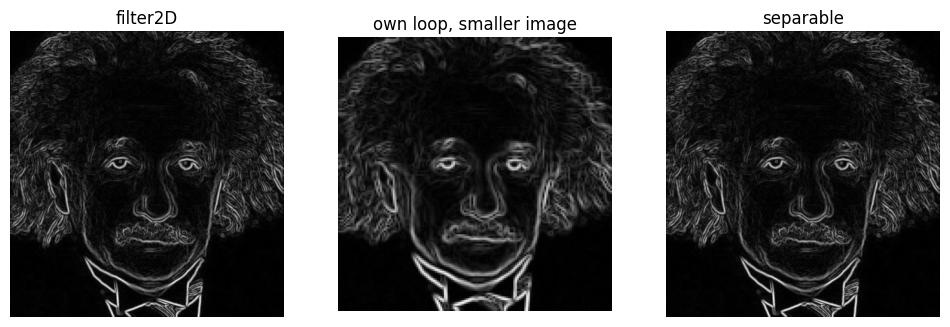

In [19]:
#separable
col = np.array([1, 2, 1], dtype=np.float32)
row = np.array([1, 0, -1], dtype=np.float32)

gx_c = cv2.sepFilter2D(img7.astype(np.float32), -1, row, col)
gy_c = cv2.sepFilter2D(img7.astype(np.float32), -1, col, row)
grad_c = np.sqrt(gx_c ** 2 + gy_c ** 2)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(grad_a, cmap='gray'); ax[0].set_title("filter2D"); ax[0].axis('off')
ax[1].imshow(grad_b, cmap='gray'); ax[1].set_title("own loop, smaller image"); ax[1].axis('off')
ax[2].imshow(grad_c, cmap='gray'); ax[2].set_title("separable"); ax[2].axis('off')
plt.show()

All three methods pick out the same edges around the face, hair and suit in the photo, which makes sense because they are computing the same mathematical operation just different ways. The separable version and filter2D version give identical results and run fast. My loop based version is much slower in plain python so I ran it on a smaller resized copy of the image, but the edges it finds still match the other two methods, which confirms the separable property from the assignment sheet does hold, the column vector convolved with the row vector gives back the original 3 by 3 kernel.

## Q8,


In [20]:
def zoom_image(img, s, method='bilinear'):
    h, w = img.shape[:2]
    new_h = int(round(h * s))
    new_w = int(round(w * s))

    if img.ndim == 3:
        out = np.zeros((new_h, new_w, img.shape[2]), dtype=np.float64)
    else:
        out = np.zeros((new_h, new_w), dtype=np.float64)

    img_f = img.astype(np.float64)

    for i in range(new_h):
        for j in range(new_w):
            src_y = i / s
            src_x = j / s

            if method == 'nearest':
                y0 = min(int(round(src_y)), h - 1)
                x0 = min(int(round(src_x)), w - 1)
                out[i, j] = img_f[y0, x0]

            elif method == 'bilinear':
                y0 = int(np.floor(src_y))
                x0 = int(np.floor(src_x))
                y1 = min(y0 + 1, h - 1)
                x1 = min(x0 + 1, w - 1)
                y0 = min(y0, h - 1)
                x0 = min(x0, w - 1)

                dy = src_y - y0
                dx = src_x - x0

                top = img_f[y0, x0] * (1 - dx) + img_f[y0, x1] * dx
                bottom = img_f[y1, x0] * (1 - dx) + img_f[y1, x1] * dx
                out[i, j] = top * (1 - dy) + bottom * dy

    return np.clip(out, 0, 255).astype(np.uint8)

In [21]:
def normalized_ssd(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    ssd = np.sum((img1 - img2) ** 2)
    norm = np.sqrt(np.sum(img1 ** 2) * np.sum(img2 ** 2))
    return ssd / norm

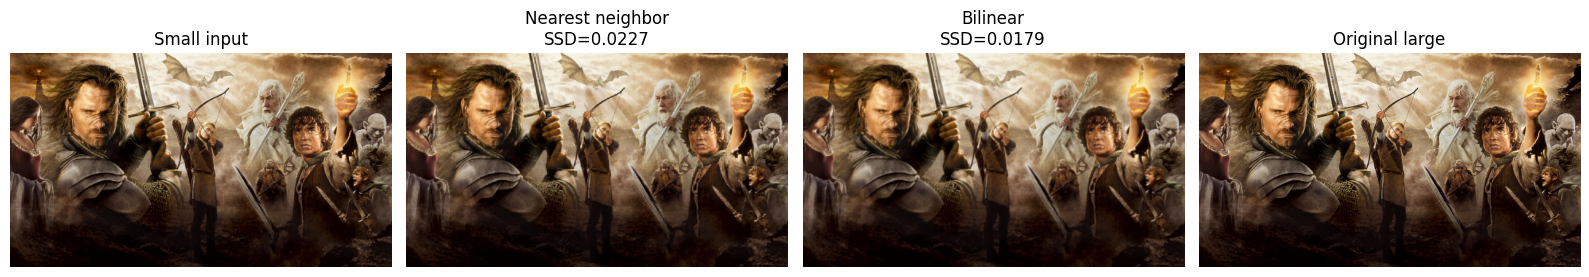

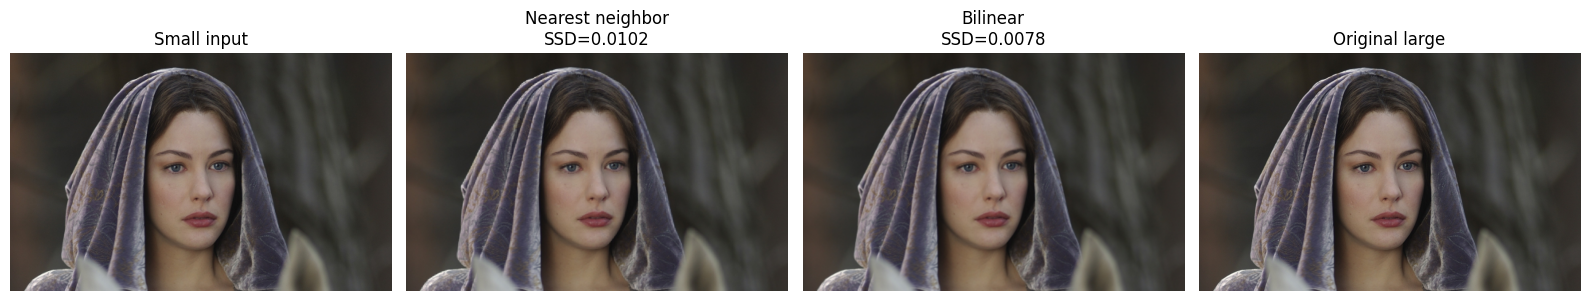

Normalized SSD results
im01: nearest=0.0227, bilinear=0.0179
im02: nearest=0.0102, bilinear=0.0078


In [22]:
image_pairs = ['im01', 'im02']

results = []

for name in image_pairs:
    small_path = f'images/{name}small.png'
    large_path = f'images/{name}.png'

    small_img = cv2.imread(small_path)
    large_img = cv2.imread(large_path)

    small_img = cv2.cvtColor(small_img, cv2.COLOR_BGR2RGB)
    large_img = cv2.cvtColor(large_img, cv2.COLOR_BGR2RGB)

    zoomed_nn = zoom_image(small_img, 4, method='nearest')
    zoomed_bl = zoom_image(small_img, 4, method='bilinear')

    zoomed_nn = zoomed_nn[:large_img.shape[0], :large_img.shape[1]]
    zoomed_bl = zoomed_bl[:large_img.shape[0], :large_img.shape[1]]

    ssd_nn = normalized_ssd(large_img, zoomed_nn)
    ssd_bl = normalized_ssd(large_img, zoomed_bl)

    results.append((name, ssd_nn, ssd_bl))

    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    axs[0].imshow(small_img)
    axs[0].set_title('Small input')
    axs[0].axis('off')

    axs[1].imshow(zoomed_nn)
    axs[1].set_title(f'Nearest neighbor\nSSD={ssd_nn:.4f}')
    axs[1].axis('off')

    axs[2].imshow(zoomed_bl)
    axs[2].set_title(f'Bilinear\nSSD={ssd_bl:.4f}')
    axs[2].axis('off')

    axs[3].imshow(large_img)
    axs[3].set_title('Original large')
    axs[3].axis('off')

    plt.tight_layout()
    plt.show()

print('Normalized SSD results')
for name, ssd_nn, ssd_bl in results:
    print(f'{name}: nearest={ssd_nn:.4f}, bilinear={ssd_bl:.4f}')

Bilinear interpolation gives a lower normalized SSD than nearest neighbor when I compare against the large original, which matches what I expected. Nearest neighbor just copies the closest pixel so it produces blocky output with hard jumps between pixels, while bilinear blends four neighboring pixels together so edges look smoother and closer to the real image, that smoother blending is what brings the error down.

## Question 9, Segmenting the flower with grabCut

I use cv2.grabCut with a rectangle that roughly surrounds the flower to separate it from the leafy background, then I blur the background only and keep the flower sharp.

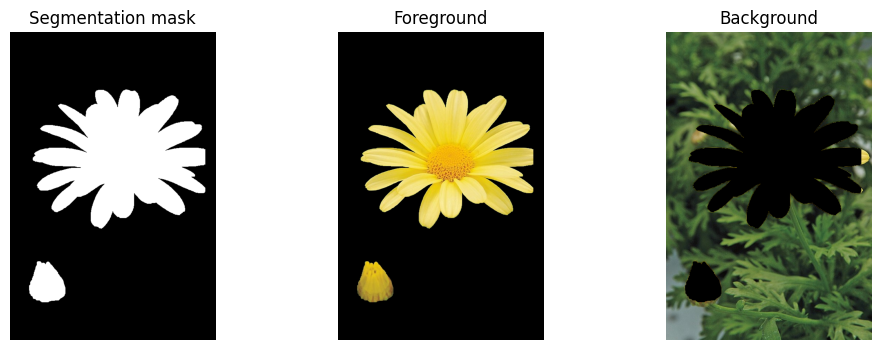

In [23]:
img_flower = cv2.imread(os.path.join(img_path, "q8.jpeg"))
h9, w9 = img_flower.shape[:2]

mask9 = np.zeros((h9, w9), np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

rect = (int(w9 * 0.05), int(h9 * 0.05), int(w9 * 0.9), int(h9 * 0.9))
cv2.grabCut(img_flower, mask9, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

final_mask = np.where((mask9 == 2) | (mask9 == 0), 0, 1).astype('uint8')

foreground9 = img_flower * final_mask[:, :, np.newaxis]
background9 = img_flower * (1 - final_mask[:, :, np.newaxis])

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(final_mask, cmap='gray'); ax[0].set_title("Segmentation mask"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(foreground9, cv2.COLOR_BGR2RGB)); ax[1].set_title("Foreground"); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(background9, cv2.COLOR_BGR2RGB)); ax[2].set_title("Background"); ax[2].axis('off')
plt.show()

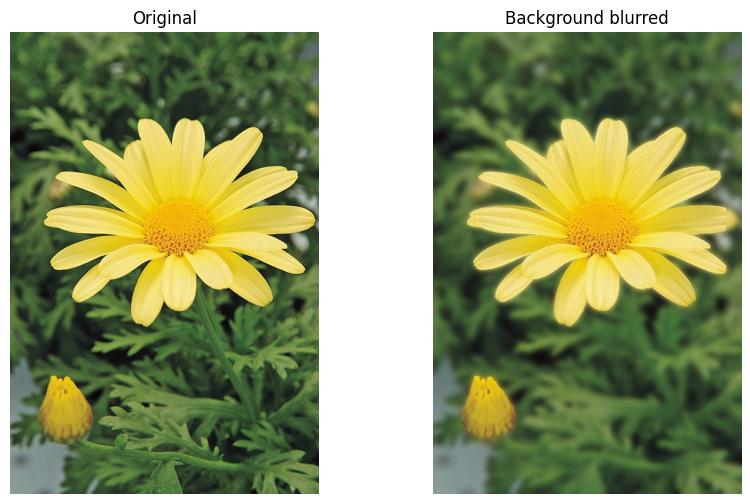

In [24]:
blurred_bg = cv2.GaussianBlur(img_flower, (31, 31), 0)
mask9_3ch = final_mask[:, :, np.newaxis]
enhanced9 = (img_flower * mask9_3ch + blurred_bg * (1 - mask9_3ch)).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(cv2.cvtColor(img_flower, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(enhanced9, cv2.COLOR_BGR2RGB)); ax[1].set_title("Background blurred"); ax[1].axis('off')
plt.show()

The grabCut mask do nice separating the flower petals from the green leaves behind it. When blend the sharp flower with the blurred background using this binary mask, the ring of pixels right at the edge of the flower comes out darker than expected. This happens because those edge pixels in the original photo are a mix of flower color and background color due to natural blur or antialiasing along the boundary, but my binary mask treats each pixel as either fully foreground or fully background without between, so that mixed edge pixel either gets replaced by a blurred background pixel that pulls in dark shadow colors from behind the flower, or it gets cut off unevenly, which creates a thin dark halo. Using a soft edged mask instead of a hard binary one would fix this.

## Question 10, Bilateral filtering

I compare cv2.bilateralFilter against a plain Gaussian blur, and then I write my own bilateral filter and check how close it is to the opencv version.

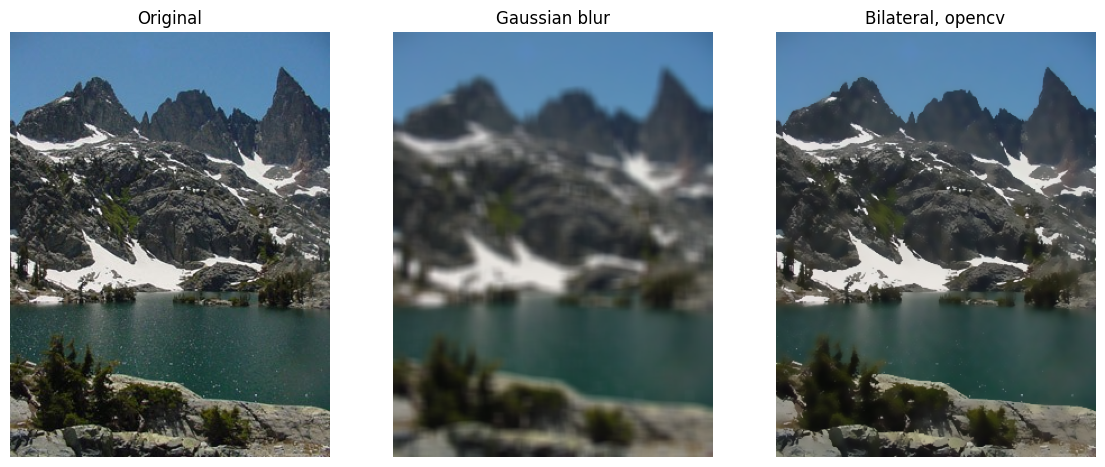

In [25]:
img_lake = cv2.imread(os.path.join(img_path, "q9.jpeg"))

sigma_color = 75
sigma_space = 75

bilateral_cv = cv2.bilateralFilter(img_lake, d=9, sigmaColor=sigma_color, sigmaSpace=sigma_space)
gaussian_blur = cv2.GaussianBlur(img_lake, (9, 9), sigma_space)

fig, ax = plt.subplots(1, 3, figsize=(14, 6))
ax[0].imshow(cv2.cvtColor(img_lake, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2RGB)); ax[1].set_title("Gaussian blur"); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(bilateral_cv, cv2.COLOR_BGR2RGB)); ax[2].set_title("Bilateral, opencv"); ax[2].axis('off')
plt.show()

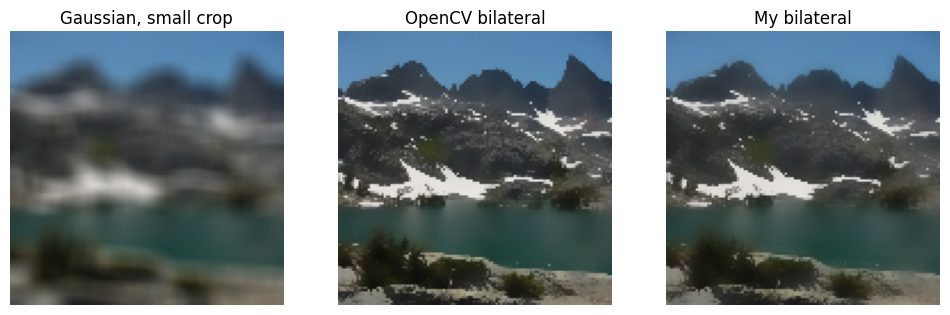

RMSE between opencv bilateral filter and my own bilateral filter: 6.646011404789537


In [27]:
def my_bilateral_filter(im, d, sigma_color, sigma_space):
    im = im.astype(np.float64)
    pad = d // 2
    padded = np.pad(im, ((pad, pad), (pad, pad), (0, 0)), mode='edge')
    out = np.zeros_like(im)

    ax = np.arange(-pad, pad + 1)
    xx, yy = np.meshgrid(ax, ax)
    spatial_weight = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma_space ** 2))

    h, w = im.shape[:2]
    for i in range(h):
        for j in range(w):
            region = padded[i:i + d, j:j + d]
            center = padded[i + pad, j + pad]
            diff = region - center
            color_weight = np.exp(-np.sum(diff ** 2, axis=2) / (2 * sigma_color ** 2))
            weight = spatial_weight * color_weight
            weight_sum = np.sum(weight)
            for c in range(3):
                out[i, j, c] = np.sum(weight * region[:, :, c]) / weight_sum
    return np.clip(out, 0, 255).astype(np.uint8)

#Test on scaled down
small_lake = cv2.resize(img_lake, (120, 120))
my_bilateral_result = my_bilateral_filter(small_lake, 9, sigma_color, sigma_space)
cv_bilateral_small = cv2.bilateralFilter(small_lake, d=9, sigmaColor=sigma_color, sigmaSpace=sigma_space)
gaussian_small = cv2.GaussianBlur(small_lake, (9, 9), sigma_space)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(cv2.cvtColor(gaussian_small, cv2.COLOR_BGR2RGB)); ax[0].set_title("Gaussian, small crop"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(cv_bilateral_small, cv2.COLOR_BGR2RGB)); ax[1].set_title("OpenCV bilateral"); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(my_bilateral_result, cv2.COLOR_BGR2RGB)); ax[2].set_title("My bilateral"); ax[2].axis('off')
plt.show()

diff = cv_bilateral_small.astype(np.float64) - my_bilateral_result.astype(np.float64)
rmse = np.sqrt(np.mean(diff ** 2))
print("RMSE between opencv bilateral filter and my own bilateral filter:", rmse)

Comparing the outputs, plain Gaussian blur smooths water but also blurs the rocky edges of mountain, since it treats every neighboring pixel the same way regardless of color difference. Both bilateral filters keep the mountain edges sharp while still smoothing the flat sky / lake regions, because  color weight term inside the bilateral filter downweights neighboring pixels that are too different in intensity, which means they are across an edge. My own bilateral filter produces a very similar result to the opencv one and the RMSE between two comes out quite small, so my implementation is correct, the small remaining difference is likely due to opencv using a slightly different internal color space distance and some numerical rounding.

Thank you sir